<a href="https://colab.research.google.com/github/JuanRebolledo69/18-03-2024/blob/master/Evaluacion_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.shape

(50000, 2)

In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["review"]).toarray()

In [ ]:
y = df["sentiment"].map({"positive": 1, "negative": 0})

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [ ]:
tf.random.set_seed(42)

#Modelo Baseline

Reutilizamos el Modelo de la Evaluacion 1 sin aplicar las tecnicas de Regularizacion, como referencia para comparar el impacto de L2 Regularization, Dropout, Batch Normalization y Early Stopping.

In [ ]:
def crear_modelo_baseline():
    model = keras.Sequential([
        layers.Dense(16, activation="relu", input_dim=X_train.shape[1]),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
modelo_baseline = crear_modelo_baseline()

history_baseline = modelo_baseline.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8625 - loss: 0.3405 - val_accuracy: 0.8594 - val_loss: 0.3407
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9065 - loss: 0.2399 - val_accuracy: 0.8686 - val_loss: 0.3231
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9193 - loss: 0.2022 - val_accuracy: 0.8754 - val_loss: 0.3273
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9377 - loss: 0.1615 - val_accuracy: 0.8750 - val_loss: 0.3553
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9527 - loss: 0.1271 - val_accuracy: 0.8739 - val_loss: 0.3961
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9578 - loss: 0.1124 - val_accuracy: 0.8730 - val_loss: 0.4616
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9653 - loss: 0.0911 - val_accuracy: 0.8590 - val_loss: 0.5288
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9739 - loss: 0.0716 - 

In [ ]:
loss_baseline, acc_baseline = modelo_baseline.evaluate(X_test, y_test)
print("Loss:", loss_baseline)
print("Accuracy:", acc_baseline)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8656 - loss: 0.6413
Loss: 0.6412789821624756
Accuracy: 0.8655999898910522


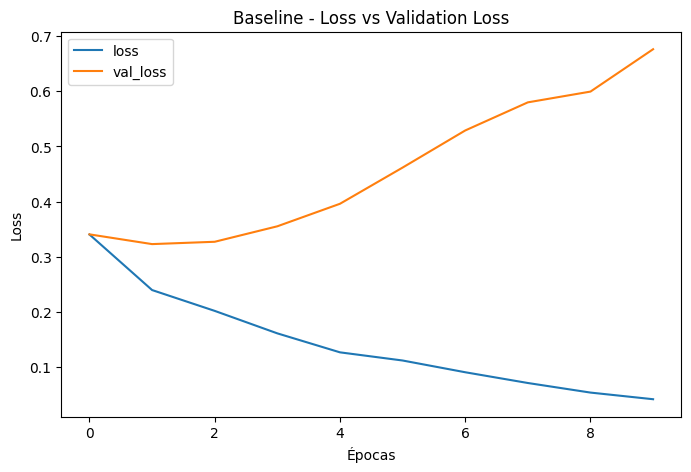

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_baseline.history['loss'], label='loss')
plt.plot(history_baseline.history['val_loss'], label='val_loss')

plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Baseline - Loss vs Validation Loss')
plt.legend()

plt.show()

### Analisis Entrenamiento Baseline

Durante el entrenamiento del modelo baseline se observa que la perdida de entrenamiento LOSS disminuye de forma constante a medida que avanzan las epocas. Sin embargo, la perdida de validación VAL_LOSS comienza a aumentar progresivamente.

Esto quiere decir que el modelo está aprendiendo muy bien los datos de entrenamiento, pero no mejora de la misma forma en los datos de validacion. Esto es una señal de overfitting, ya que el modelo comienza a memorizar patrones del conjunto de entrenamiento en lugar de generalizar correctamente a datos nuevos.


#L2 Regularization

La regularizacion L2 agrega una penalizacion a los pesos del modelo durante el entrenamiento. Su objetivo es evitar que los pesos crezcan excesivamente y reducir el riesgo de overfitting.

##Primera Prueba: L2 λ=0.001

In [ ]:
from tensorflow.keras import regularizers

def crear_modelo_l2_001():

    model = keras.Sequential([
        layers.Dense(
            16,
            activation="relu",
            input_dim=X_train.shape[1],
            kernel_regularizer=regularizers.l2(0.001)
        ),

        layers.Dense(
            8,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
modelo_l2_001 = crear_modelo_l2_001()

history_l2_001 = modelo_l2_001.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8596 - loss: 0.3927 - val_accuracy: 0.8500 - val_loss: 0.4246
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8935 - loss: 0.3251 - val_accuracy: 0.8495 - val_loss: 0.4273
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8983 - loss: 0.3135 - val_accuracy: 0.8535 - val_loss: 0.4197
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9037 - loss: 0.3014 - val_accuracy: 0.8575 - val_loss: 0.4079
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9084 - loss: 0.2899 - val_accuracy: 0.8609 - val_loss: 0.4014
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9139 - loss: 0.2777 - val_accuracy: 0.8635 - val_loss: 0.4074
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9174 - loss: 0.2707 - val_accuracy: 0.8606 - val_loss: 0.4148
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9201 - loss: 0.2642 - 

In [ ]:
loss_l2_001, acc_l2_001 = modelo_l2_001.evaluate(X_test, y_test)

print("Loss:", loss_l2_001)
print("Accuracy:", acc_l2_001)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8663 - loss: 0.4141
Loss: 0.41406747698783875
Accuracy: 0.8662999868392944


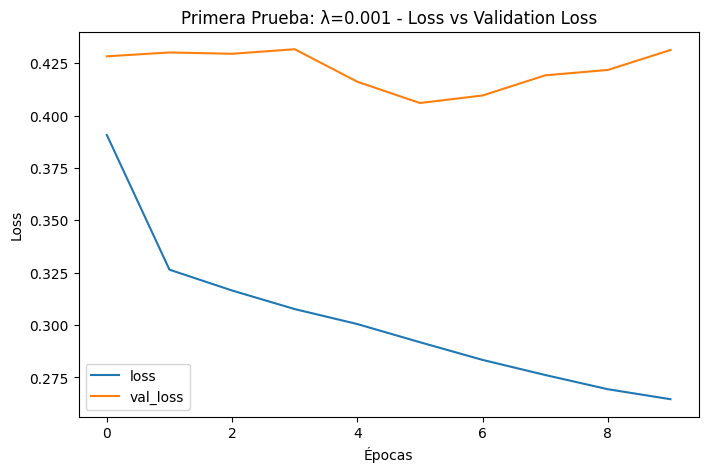

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_l2_001.history["loss"], label="loss")
plt.plot(history_l2_001.history["val_loss"], label="val_loss")

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Primera Prueba: λ=0.001 - Loss vs Validation Loss")
plt.legend()

plt.show()

##Segunda Prueba: L2 λ=0.01

In [ ]:
from tensorflow.keras import regularizers

def crear_modelo_l2_01():

    model = keras.Sequential([
        layers.Dense(
            16,
            activation="relu",
            input_dim=X_train.shape[1],
            kernel_regularizer=regularizers.l2(0.01)
        ),

        layers.Dense(
            8,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.01)
        ),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
modelo_l2_01 = crear_modelo_l2_01()

history_l2_01 = modelo_l2_01.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8489 - loss: 0.5287 - val_accuracy: 0.8298 - val_loss: 0.5450
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8663 - loss: 0.4622 - val_accuracy: 0.8291 - val_loss: 0.5355
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8688 - loss: 0.4435 - val_accuracy: 0.8335 - val_loss: 0.5157
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8721 - loss: 0.4254 - val_accuracy: 0.8390 - val_loss: 0.4946
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8748 - loss: 0.4098 - val_accuracy: 0.8405 - val_loss: 0.4860
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8771 - loss: 0.3978 - val_accuracy: 0.8414 - val_loss: 0.4803
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8797 - loss: 0.3882 - val_accuracy: 0.8428 - val_loss: 0.4744
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8820 - loss: 0.3795 - 

In [ ]:
loss_l2_01, acc_l2_01 = modelo_l2_01.evaluate(X_test, y_test)

print("Loss:", loss_l2_01)
print("Accuracy:", acc_l2_01)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8608 - loss: 0.4224
Loss: 0.4224168062210083
Accuracy: 0.86080002784729


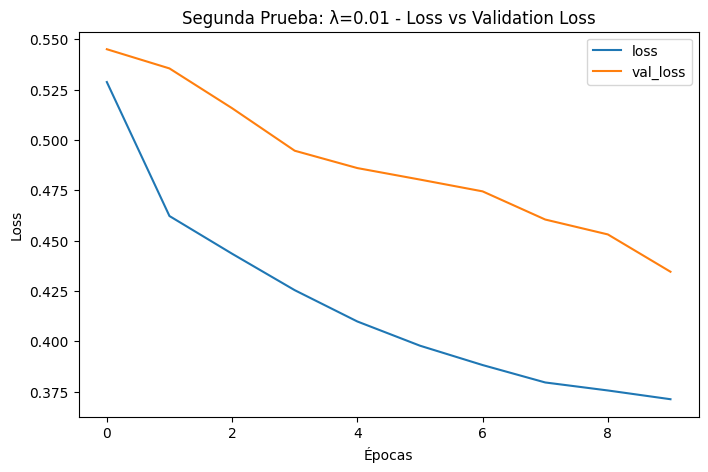

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_l2_01.history["loss"], label="loss")
plt.plot(history_l2_01.history["val_loss"], label="val_loss")

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Segunda Prueba: λ=0.01 - Loss vs Validation Loss")
plt.legend()

plt.show()

###Análisis de L2 Regularization

Al aplicar regularizacion L2 se observa una disminucion del overfitting respecto al modelo baseline. La diferencia entre la perdida de entrenamiento LOSS y la perdida de validacion VAL_LOSS se reduce considerablemente, indicando una mejor capacidad de generalizacion.

Con λ = 0.001 el modelo mantiene un rendimiento aceptable y reduce parcialmente el sobreajuste. Sin embargo, con λ = 0.01 la separación entre ambas curvas es aún menor, evidenciando un control más efectivo del overfitting.

Aunque la accuracy final disminuye ligeramente respecto al baseline, el comportamiento del modelo es mas estable y generaliza mejor sobre datos no vistos.

#Dropout
Tecnica de regularizacion que desactiva aleatoriamente una fracción de neuronas durante el entrenamiento. Su objetivo es evitar que el modelo dependa excesivamente de determinadas neuronas y reducir el riesgo de overfitting.

##Primera Prueba: Dropout 0.2

In [ ]:
def crear_modelo_dropout_02():

    model = keras.Sequential([
        layers.Dense(
            16,
            activation="relu",
            input_dim=X_train.shape[1]
        ),

        layers.Dropout(0.2),

        layers.Dense(
            8,
            activation="relu"
        ),

        layers.Dropout(0.2),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
modelo_dropout_02 = crear_modelo_dropout_02()

history_dropout_02 = modelo_dropout_02.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8220 - loss: 0.4191 - val_accuracy: 0.8823 - val_loss: 0.2974
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8957 - loss: 0.2727 - val_accuracy: 0.8815 - val_loss: 0.2934
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9155 - loss: 0.2267 - val_accuracy: 0.8749 - val_loss: 0.3209
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9295 - loss: 0.1950 - val_accuracy: 0.8805 - val_loss: 0.3428
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9388 - loss: 0.1694 - val_accuracy: 0.8770 - val_loss: 0.3875
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9478 - loss: 0.1493 - val_accuracy: 0.8734 - val_loss: 0.3868
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9539 - loss: 0.1317 - val_accuracy: 0.8744 - val_loss: 0.4153
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9554 - loss: 0.1229 -

In [ ]:
loss_dropout_02, acc_dropout_02 = modelo_dropout_02.evaluate(
    X_test,
    y_test
)

print("Loss:", loss_dropout_02)
print("Accuracy:", acc_dropout_02)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8735 - loss: 0.4559
Loss: 0.45587003231048584
Accuracy: 0.8734999895095825


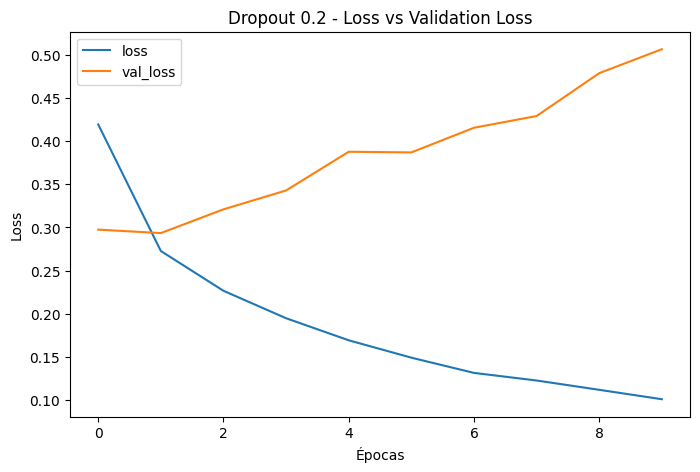

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_dropout_02.history["loss"],
    label="loss"
)

plt.plot(
    history_dropout_02.history["val_loss"],
    label="val_loss"
)

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Dropout 0.2 - Loss vs Validation Loss")
plt.legend()

plt.show()

##Segunda Prueba: Dropout 0.5

In [ ]:
def crear_modelo_dropout_05():

    model = keras.Sequential([
        layers.Dense(
            16,
            activation="relu",
            input_dim=X_train.shape[1]
        ),

        layers.Dropout(0.5),

        layers.Dense(
            8,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
modelo_dropout_05 = crear_modelo_dropout_05()

history_dropout_05 = modelo_dropout_05.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7398 - loss: 0.5285 - val_accuracy: 0.8720 - val_loss: 0.3420
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8410 - loss: 0.3989 - val_accuracy: 0.8816 - val_loss: 0.3120
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8586 - loss: 0.3610 - val_accuracy: 0.8850 - val_loss: 0.3093
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8712 - loss: 0.3295 - val_accuracy: 0.8749 - val_loss: 0.3092
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8752 - loss: 0.3165 - val_accuracy: 0.8795 - val_loss: 0.3080
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8829 - loss: 0.2948 - val_accuracy: 0.8788 - val_loss: 0.3162
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8899 - loss: 0.2777 - val_accuracy: 0.8840 - val_loss: 0.3301
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8921 - loss: 0.2695 - 

In [ ]:
loss_dropout_05, acc_dropout_05 = modelo_dropout_05.evaluate(
    X_test,
    y_test
)

print("Loss:", loss_dropout_05)
print("Accuracy:", acc_dropout_05)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8797 - loss: 0.3146
Loss: 0.3146402835845947
Accuracy: 0.8797000050544739


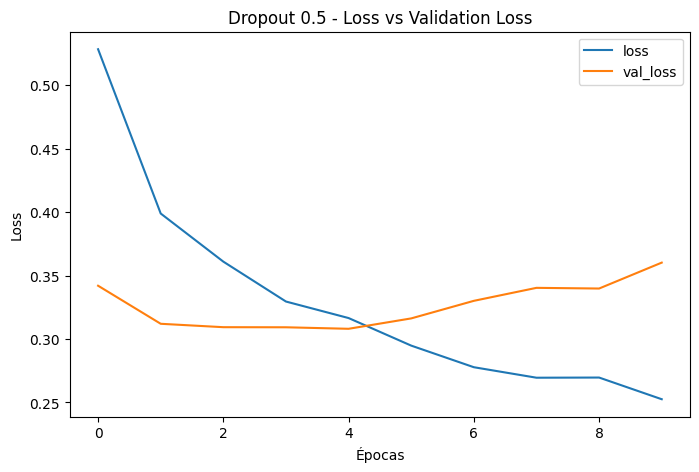

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_dropout_05.history["loss"],
    label="loss"
)

plt.plot(
    history_dropout_05.history["val_loss"],
    label="val_loss"
)

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Dropout 0.5 - Loss vs Validation Loss")
plt.legend()

plt.show()

### Análisis de Dropout

La tecnica de Dropout fue implementada con tasas de 0.2 y 0.5, desactivando aleatoriamente una fraccion de neuronas durante el entrenamiento para reducir la dependencia excesiva entre ellas.

En ambos casos se observo una mejora en la accuracy respecto al modelo baseline, alcanzando aproximadamente un 87.3% con Dropout 0.2 y un 88.0% con Dropout 0.5. Esto indica una mejor capacidad predictiva sobre datos no vistos.

Al analizar las curvas de entrenamiento y validacion se observa que la perdida de validacion (val_loss) comienza a aumentar despues de varias epocas, mientras que la perdida de entrenamiento continua disminuyendo. Esto sugiere que aun existe cierto grado de overfitting.

Sin embargo, la separacion entre ambas curvas es menor que en el modelo baseline, especialmente durante las primeras epocas, lo que indica que Dropout contribuye a mejorar la generalizacion del modelo. Entre las configuraciones evaluadas, Dropout 0.5 obtuvo la mejor accuracy de toda la evaluacion, alcanzando aproximadamente un 88%.


#Batch Normalization

Batch Normalization es una tecnica que normaliza las salidas de las capas ocultas durante el entrenamiento, manteniendo distribuciones más estables entre lotes de datos.

In [ ]:
def crear_modelo_batchnorm():

    model = keras.Sequential([
        layers.Dense(
            16,
            activation="relu",
            input_dim=X_train.shape[1]
        ),

        layers.BatchNormalization(),

        layers.Dense(
            8,
            activation="relu"
        ),

        layers.BatchNormalization(),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
modelo_batchnorm = crear_modelo_batchnorm()

history_batchnorm = modelo_batchnorm.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8374 - loss: 0.3673 - val_accuracy: 0.8779 - val_loss: 0.2948
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9035 - loss: 0.2435 - val_accuracy: 0.8741 - val_loss: 0.3012
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9250 - loss: 0.1950 - val_accuracy: 0.8670 - val_loss: 0.3398
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9400 - loss: 0.1611 - val_accuracy: 0.8635 - val_loss: 0.3811
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9523 - loss: 0.1308 - val_accuracy: 0.8629 - val_loss: 0.4295
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9621 - loss: 0.1066 - val_accuracy: 0.8666 - val_loss: 0.4452
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9680 - loss: 0.0919 - val_accuracy: 0.8618 - val_loss: 0.5064
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9747 - loss: 0.0755 - 

In [ ]:
loss_batchnorm, acc_batchnorm = modelo_batchnorm.evaluate(
    X_test,
    y_test
)

print("Loss:", loss_batchnorm)
print("Accuracy:", acc_batchnorm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8549 - loss: 0.6384
Loss: 0.638373613357544
Accuracy: 0.8549000024795532


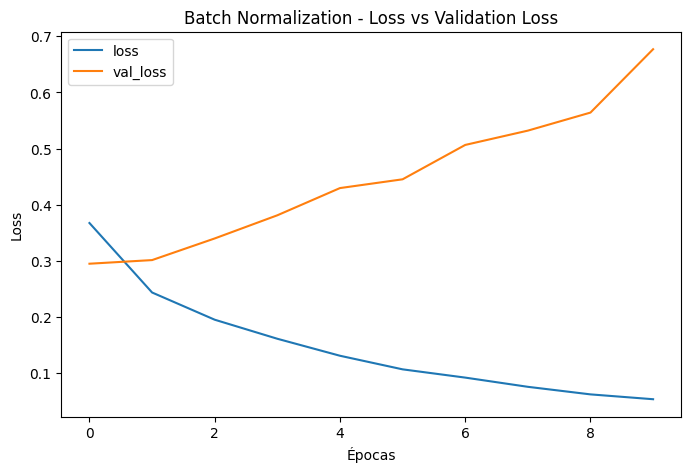

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_batchnorm.history["loss"],
    label="loss"
)

plt.plot(
    history_batchnorm.history["val_loss"],
    label="val_loss"
)

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Batch Normalization - Loss vs Validation Loss")
plt.legend()

plt.show()

### Análisis de Batch Normalization

Batch Normalization fue incorporada entre las capas ocultas con el objetivo de estabilizar las distribuciones internas de activación y facilitar el proceso de aprendizaje.

Sin embargo, al comparar los resultados obtenidos con el modelo baseline, no se observaron mejoras significativas en la accuracy ni en la perdida de validacion. Ademas, las curvas de entrenamiento y validacion continuan separandose a medida que avanzan las epocas, evidenciando la presencia de overfitting.


#Early Stopping

Early Stopping es una tecnica que detiene automaticamente el entrenamiento cuando la metrica de validacion deja de mejorar. Su objetivo es evitar que el modelo continue entrenandose una vez que comienza el sobreajuste.

##Primera Prueba: patience = 5

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
modelo_es_5 = crear_modelo_baseline()

In [ ]:
early_stop_5 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history_es_5 = modelo_es_5.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_5]
)

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9141 - loss: 0.2200 - val_accuracy: 0.8686 - val_loss: 0.3392
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9290 - loss: 0.1811 - val_accuracy: 0.8724 - val_loss: 0.3552
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9432 - loss: 0.1479 - val_accuracy: 0.8656 - val_loss: 0.4039
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9559 - loss: 0.1192 - val_accuracy: 0.8634 - val_loss: 0.4602
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9661 - loss: 0.0934 - val_accuracy: 0.8616 - val_loss: 0.5193
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9704 - loss: 0.0811 - val_accuracy: 0.8645 - val_loss: 0.5383


In [ ]:
loss_es_5, acc_es_5 = modelo_es_5.evaluate(
    X_test,
    y_test
)

print("Loss:", loss_es_5)
print("Accuracy:", acc_es_5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8767 - loss: 0.3142
Loss: 0.3142138123512268
Accuracy: 0.8766999840736389


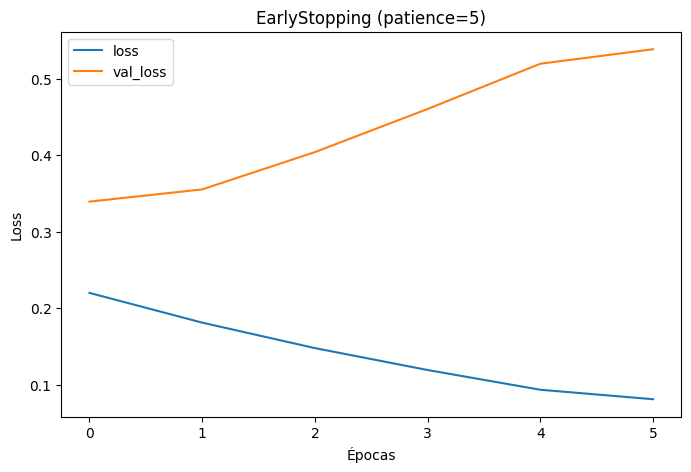

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_es_5.history["loss"], label="loss")
plt.plot(history_es_5.history["val_loss"], label="val_loss")

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("EarlyStopping (patience=5)")
plt.legend()

plt.show()

##Segunda Prueba: patience = 20

In [ ]:
modelo_es_20 = crear_modelo_baseline()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stop_20 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

In [ ]:
history_es_20 = modelo_es_20.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_20]
)

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8488 - loss: 0.3596 - val_accuracy: 0.8636 - val_loss: 0.3403
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9092 - loss: 0.2350 - val_accuracy: 0.8666 - val_loss: 0.3362
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9257 - loss: 0.1926 - val_accuracy: 0.8687 - val_loss: 0.3471
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9393 - loss: 0.1596 - val_accuracy: 0.8683 - val_loss: 0.3743
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9525 - loss: 0.1276 - val_accuracy: 0.8641 - val_loss: 0.4259
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9601 - loss: 0.1090 - val_accuracy: 0.8630 - val_loss: 0.5011
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9654 - loss: 0.0961 - val_accuracy: 0.8698 - val_loss: 0.4899
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9748 - loss: 0.0747 - 

In [ ]:
loss_es_20, acc_es_20 = modelo_es_20.evaluate(
    X_test,
    y_test
)

print("Loss:", loss_es_20)
print("Accuracy:", acc_es_20)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8742 - loss: 0.3191
Loss: 0.31907954812049866
Accuracy: 0.8741999864578247


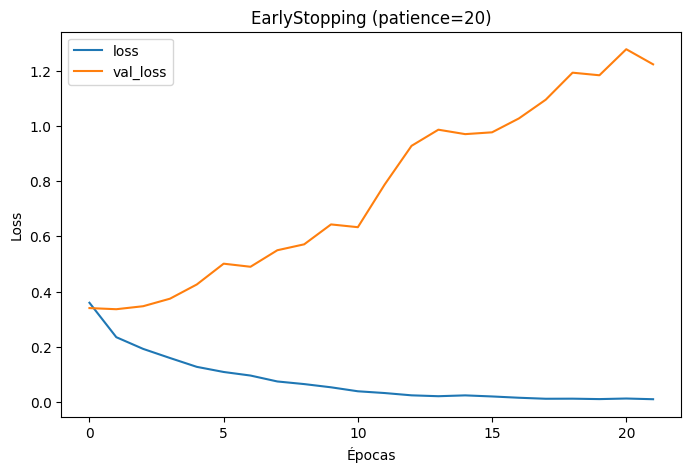

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_es_20.history["loss"], label="loss")
plt.plot(history_es_20.history["val_loss"], label="val_loss")

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("EarlyStopping (patience=20)")
plt.legend()

plt.show()

### Análisis de Early Stopping

Early Stopping permitio detener automaticamente el entrenamiento cuando la perdida de validación dejo de mejorar. Se compararon dos configuraciones: "patience = 5" y "patience = 20".

Con "patience = 5", el entrenamiento se detuvo tempranamente, obteniendo una accuracy cercana al 87.7% y una perdida de aproximadamente 0.31. Por otro lado, con "patience = 20", el modelo continuo entrenandose durante más epocas, alcanzando una accuracy ligeramente inferior y una perdida similar.

Los resultados muestran que aumentar la paciencia no produjo mejoras significativas. Por el contrario, la configuracion con "patience = 5" logro un mejor equilibrio entre rendimiento, tiempo de entrenamiento y capacidad de generalizacion.

# Modelo Combinado

Finalmente, se construyo un modelo que combina las tecnicas de regularizacion que mostraron mejores resultados individuales durante la evaluacion.

Se incorporo regularizacion L2 con λ = 0.01 para limitar el crecimiento excesivo de los pesos, Dropout con una tasa de 0.5 para reducir la dependencia entre neuronas y Early Stopping con patience = 5 para detener automaticamente el entrenamiento cuando la perdida de validacion deja de mejorar.


In [ ]:
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

def crear_modelo_final():

    model = keras.Sequential([

        layers.Dense(
            16,
            activation="relu",
            input_dim=X_train.shape[1],
            kernel_regularizer=regularizers.l2(0.01)
        ),

        layers.Dropout(0.5),

        layers.Dense(
            8,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.01)
        ),

        layers.Dropout(0.5),

        layers.Dense(
            1,
            activation="sigmoid"
        )

    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
early_stop_final = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
modelo_final = crear_modelo_final()

history_final = modelo_final.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_final]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7182 - loss: 0.6802 - val_accuracy: 0.8329 - val_loss: 0.5709
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7974 - loss: 0.5938 - val_accuracy: 0.8334 - val_loss: 0.5341
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8022 - loss: 0.5735 - val_accuracy: 0.8163 - val_loss: 0.5403
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8033 - loss: 0.5676 - val_accuracy: 0.8481 - val_loss: 0.5011
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8083 - loss: 0.5635 - val_accuracy: 0.8624 - val_loss: 0.4823
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8022 - loss: 0.5707 - val_accuracy: 0.8489 - val_loss: 0.4960
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8086 - loss: 0.5628 - val_accuracy: 0.8474 - val_loss: 0.4949
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8057 - loss: 0.5658 - 

In [ ]:
loss_final, acc_final = modelo_final.evaluate(
    X_test,
    y_test
)

print("Loss:", loss_final)
print("Accuracy:", acc_final)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8687 - loss: 0.4736
Loss: 0.4735628366470337
Accuracy: 0.8687000274658203


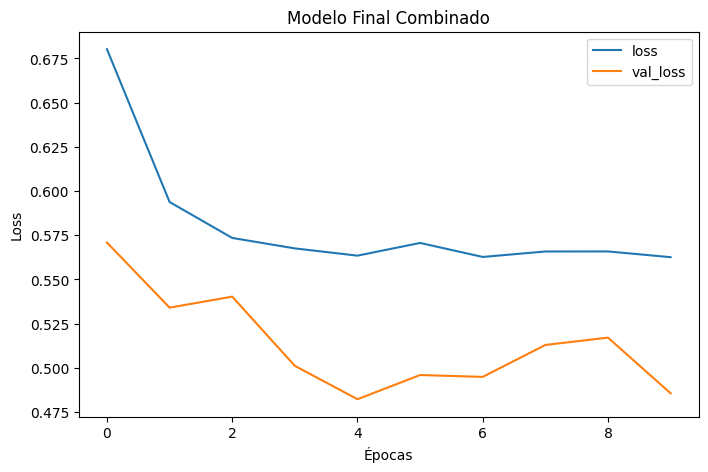

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_final.history["loss"],
    label="loss"
)

plt.plot(
    history_final.history["val_loss"],
    label="val_loss"
)

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Modelo Final Combinado")
plt.legend()

plt.show()

## Conclusiones

En esta evaluacion se aplicaron distintas tecnicas de regularizacion sobre un modelo MLP para clasificacion de reseñas de peliculas, con el objetivo de reducir el overfitting y mejorar la capacidad de generalizacion.
Los resultados mostraron que cada tecnica tuvo un impacto diferente sobre el comportamiento del modelo. La regularizacion L2 permitio reducir la diferencia entre las curvas de entrenamiento y validacion, siendo λ = 0.001 la configuracion que obtuvo el mejor equilibrio entre rendimiento y control del sobreajuste dentro de las pruebas realizadas.
La tecnica de Dropout fue la que obtuvo la mayor accuracy individual, alcanzando aproximadamente un 88% con una tasa de 0.5, lo que demuestra una mejor capacidad predictiva sobre datos no vistos.
Por otro lado, Batch Normalization no presento mejoras relevantes para este conjunto de datos. En cambio, Early Stopping permitio detener el entrenamiento antes de que el modelo continuara sobreajustandose, siendo la configuracion con patience = 5 la mas eficiente en terminos de rendimiento y tiempo de entrenamiento.
Finalmente, la combinacion de L2, Dropout y Early Stopping produjo un modelo estable y con menor tendencia al sobreajuste, aunque no supero el rendimiento obtenido por las mejores tecnicas aplicadas individualmente. Esto demuestra que agregar mas mecanismos de regularizacion no siempre genera mejores resultados y que es necesario encontrar un equilibrio adecuado entre capacidad de aprendizaje y generalizacion.